# Assignment : Healthcare Risk Prediction - Machine Learning vs Neural Networks

# **  1. A Traditional Machine Learning model**

First 5 rows:
    patient_id  age   bmi  exercise_hours_per_week  smoker  blood_pressure  \
0           1   31  18.3                      1.5       0           119.1   
1           2   44  26.3                      3.1       0           120.5   
2           3   43  24.2                      4.8       0           130.3   
3           4   32  25.0                      6.0       0           119.5   
4           5   28  22.1                      4.2       1           127.4   

   diabetes  
0         0  
1         0  
2         0  
3         0  
4         0  

Shape: (6000, 7)

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               6000 non-null   int64  
 1   age                      6000 non-null   int64  
 2   bmi                      6000 non-null   float64
 3   exercise_hours_per_week  6000 n

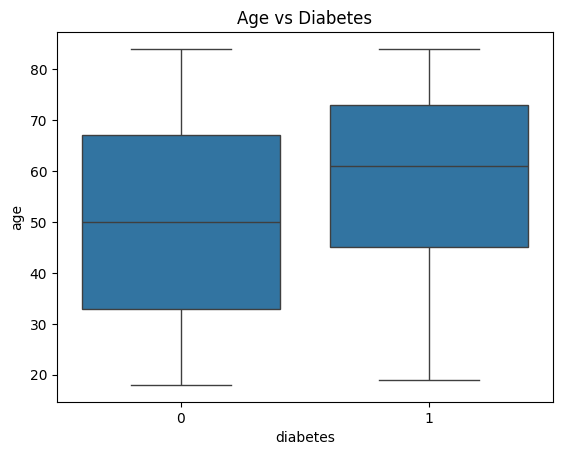

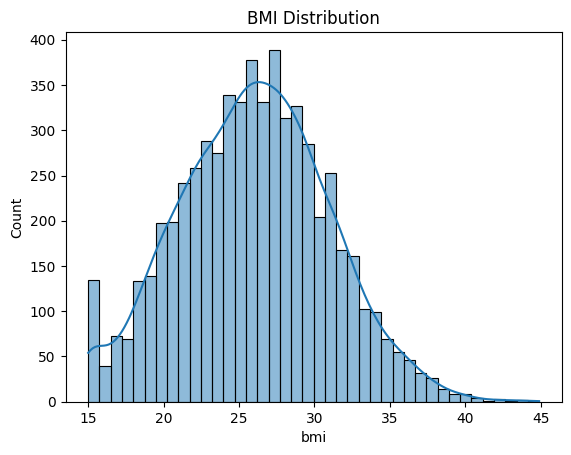

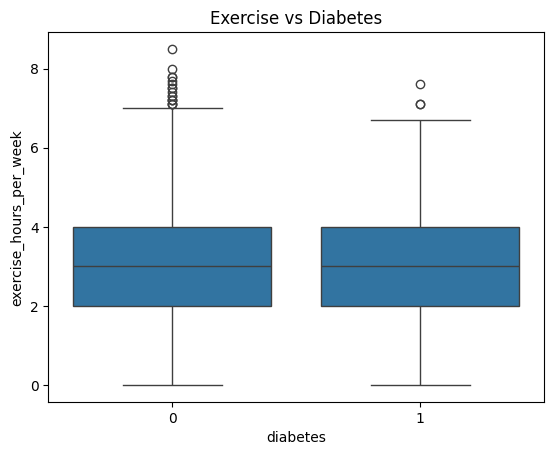

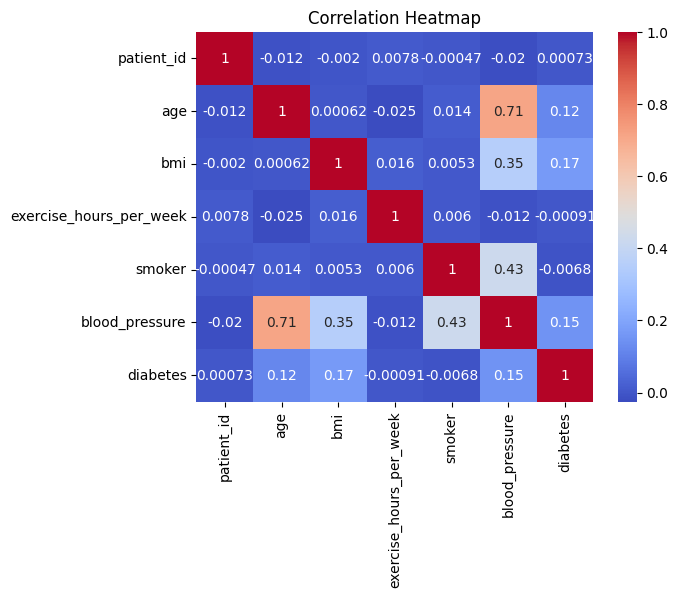


===== MODEL PERFORMANCE =====
Accuracy : 0.65
Precision: 0.15178571428571427
Recall   : 0.6296296296296297
F1 Score : 0.2446043165467626

Confusion Matrix:
 [[712 380]
 [ 40  68]]

Feature Importance:
                    Feature  Importance
1                      bmi    0.524337
0                      age    0.337278
4           blood_pressure    0.272897
2  exercise_hours_per_week    0.032847
3                   smoker   -0.175619


In [2]:




# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score


# ================================
# 2. Load Dataset
# ================================
df = pd.read_csv("healthcare_dataset.csv")

print("First 5 rows:\n", df.head())


# ================================
# 3. Data Exploration
# ================================
print("\nShape:", df.shape)
print("\nInfo:\n")
print(df.info())

print("\nMissing Values:\n", df.isnull().sum())

print("\nStatistical Summary:\n", df.describe())


# ================================
# 4. Data Visualization
# ================================

# Age vs Diabetes
plt.figure()
sns.boxplot(x='diabetes', y='age', data=df)
plt.title("Age vs Diabetes")
plt.show()

# BMI Distribution
plt.figure()
sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")
plt.show()

# Exercise vs Diabetes
plt.figure()
sns.boxplot(x='diabetes', y='exercise_hours_per_week', data=df)
plt.title("Exercise vs Diabetes")
plt.show()

# Correlation Heatmap
plt.figure()
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# ================================
# 5. Data Preprocessing
# ================================

# Drop unnecessary column
df = df.drop('patient_id', axis=1)

# Split features and target
X = df.drop('diabetes', axis=1)
y = df['diabetes']


# ================================
# 6. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ================================
# 7. Feature Scaling
# ================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ================================
# 8. Train Model
# ================================
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)


# ================================
# 9. Predictions
# ================================
y_pred = model.predict(X_test)


# ================================
# 10. Model Evaluation
# ================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n===== MODEL PERFORMANCE =====")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nConfusion Matrix:\n", cm)


# ================================
# 11. Feature Importance
# ================================
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n", feature_importance)



# 2.A Neural Network (Deep Learning) model

Feature columns:
Index(['age', 'bmi', 'exercise_hours_per_week', 'smoker', 'blood_pressure'], dtype='object')

X shape: (6000, 5)
y shape: (6000,)

Train-Test Split Done
X_train shape: (4800, 5)
X_test shape : (1200, 5)

===== Neural Network Architecture =====
- Input Layer   : 5 input features
- Hidden Layer 1: 32 neurons, ReLU activation
- Hidden Layer 2: 16 neurons, ReLU activation
- Output Layer  : 1 neuron, Sigmoid activation
- Optimizer     : Adam
- Loss Function : Binary Crossentropy
- Metric Used   : Accuracy
Epoch 1/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8844 - loss: 0.4066 - val_accuracy: 0.9083 - val_loss: 0.2981
Epoch 2/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9099 - loss: 0.2928 - val_accuracy: 0.9083 - val_loss: 0.2861
Epoch 3/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9099 - loss: 0.2866 - val_accuracy: 0.9083 - val_loss: 0.2825
Epoch 4/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9099 - loss: 0.2845 - v

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


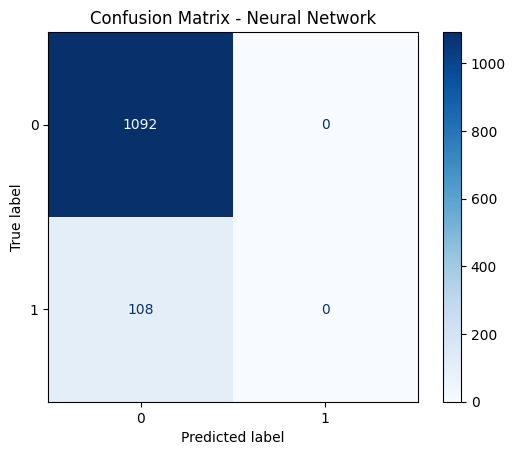

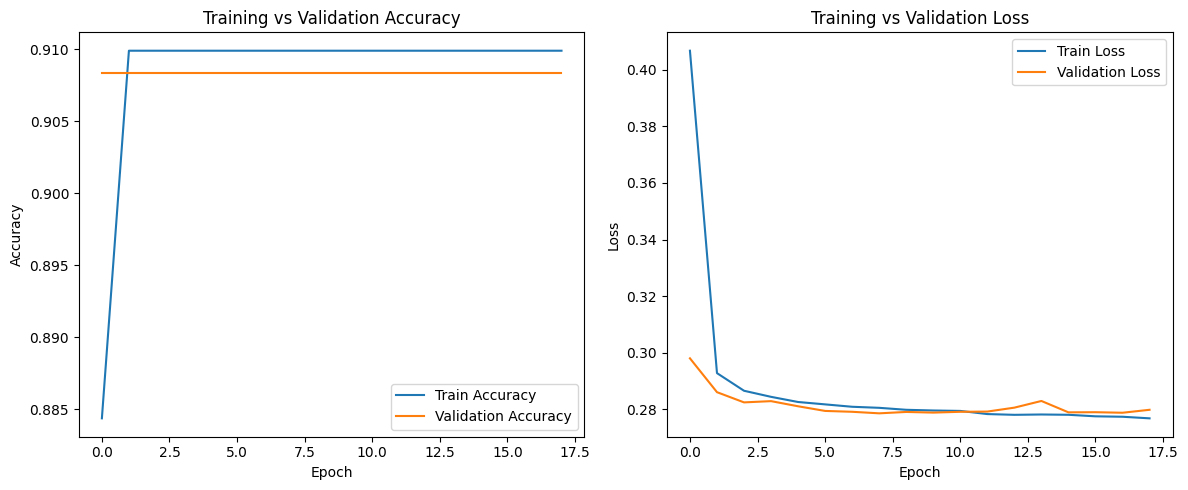

In [3]:
# =========================================
# Part 3 — Neural Network Model
# Healthcare Risk Prediction
# =========================================

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

# 2. Load dataset
data = pd.read_csv("healthcare_dataset.csv")

# 3. Separate features and target
X = data.drop(["patient_id", "diabetes"], axis=1)
y = data["diabetes"]

print("Feature columns:")
print(X.columns)
print("\nX shape:", X.shape)
print("y shape:", y.shape)

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain-Test Split Done")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

# 5. Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Build Sequential Neural Network
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 7. Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 8. Show architecture in bullet format
print("\n===== Neural Network Architecture =====")
print(f"- Input Layer   : {X_train_scaled.shape[1]} input features")
print("- Hidden Layer 1: 32 neurons, ReLU activation")
print("- Hidden Layer 2: 16 neurons, ReLU activation")
print("- Output Layer  : 1 neuron, Sigmoid activation")
print("- Optimizer     : Adam")
print("- Loss Function : Binary Crossentropy")
print("- Metric Used   : Accuracy")

# 9. Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# 10. Train model
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# 11. Evaluate on test data
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print("\n===== Neural Network Test Performance =====")
print("Test Loss     :", round(test_loss, 4))
print("Test Accuracy :", round(test_accuracy, 4))

# 12. Predictions
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# 13. Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 14. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Neural Network")
plt.grid(False)
plt.show()

# 15. Training performance visualization
plt.figure(figsize=(12, 5))

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()